In [1]:
import os
import s3fs
import fsspec
import boto3
import xarray as xr
import geopandas as gpd
import xarray as xr

In [2]:
scratch = os.environ['SCRATCH_BUCKET'] 

's3://nasa-cryo-scratch/jkingslake'

In [11]:
s3 = s3fs.S3FileSystem()
ff10m_zarrs = s3.ls(scratch + '/Daily-2km-zarr/ff10m/')
len(ff10m_zarrs)

188

In [12]:
s3 = s3fs.S3FileSystem()
t2m_zarrs = s3.ls(scratch + '/Daily-2km-zarr/t2m/')
len(t2m_zarrs)

188

In [13]:
s3 = s3fs.S3FileSystem()
precip_zarrs = s3.ls(scratch + '/Daily-2km-zarr/precip/')
len(precip_zarrs)

188

In [14]:
s3 = s3fs.S3FileSystem()
snowmelt_zarrs = s3.ls(scratch + '/Daily-2km-zarr/snowmelt/')
len(snowmelt_zarrs)

188

In [2]:
import pandas as pd
import s3fs

DATASETS = ["ff10m", "precip", "t2m", "snowmelt"]

S3_BASE = "nasa-cryo-scratch/jkingslake/Daily-2km-zarr"

fs = s3fs.S3FileSystem()

rows = []

for dataset in DATASETS:

    dataset_path = f"{S3_BASE}/{dataset}"

    try:
        zarrs = fs.ls(dataset_path, detail=False)

    except Exception as e:
        print(f"Could not list {dataset}: {e}")
        continue

    zarrs = [z for z in zarrs if z.endswith(".zarr")]

    print(f"{dataset}: {len(zarrs)} zarr stores")

    for zarr_path in zarrs:

        try:
            files = fs.find(
                zarr_path,
                detail=True,
            )

            size_bytes = sum(
                f["size"]
                for f in files.values()
            )

            rows.append({
                "dataset": dataset,
                "zarr_name": zarr_path.split("/")[-1],
                "zarr_path": f"s3://{zarr_path}",
                "size_mb": size_bytes / 1e6,
                "n_files": len(files),
                "has_zmetadata": (
                    zarr_path + "/.zmetadata"
                ) in files,
            })

        except Exception as e:

            rows.append({
                "dataset": dataset,
                "zarr_name": zarr_path.split("/")[-1],
                "zarr_path": f"s3://{zarr_path}",
                "size_mb": None,
                "n_files": None,
                "has_zmetadata": False,
                "error": str(e),
            })

df = pd.DataFrame(rows)

df

ff10m: 188 zarr stores
precip: 188 zarr stores
t2m: 188 zarr stores
snowmelt: 188 zarr stores


,dataset,zarr_name,zarr_path,size_mb,n_files,has_zmetadata
0,ff10m,ff10m.1979_AMJ.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,894.754988,33,True
1,ff10m,ff10m.1979_JAS.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,902.776493,33,True
2,ff10m,ff10m.1979_JFM.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,146.697116,17,True
3,ff10m,ff10m.1979_OND.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,901.520007,33,True
4,ff10m,ff10m.1980_AMJ.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,794.460052,31,True
...,...,...,...,...,...,...
747,snowmelt,snowmelt.2024_OND.BN_RACMO2.3p2_ANT27_ERA5_3h....,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,84.887701,1038,True
748,snowmelt,snowmelt.2025_AMJ.BN_RACMO2.3p2_ANT27_ERA5_3h....,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,21.313741,1038,True
749,snowmelt,snowmelt.2025_JAS.BN_RACMO2.3p2_ANT27_ERA5_3h....,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,22.706158,1038,True
750,snowmelt,snowmelt.2025_JFM.BN_RACMO2.3p2_ANT27_ERA5_3h....,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,70.729341,974,True


In [20]:
df['size_mb'].to_list()

[894.754988,
 902.776493,
 146.697116,
 901.520007,
 794.460052,
 902.577965,
 894.843136,
 901.134498,
 344.858494,
 898.688089,
 884.371828,
 901.322382,
 696.278481,
 902.571299,
 886.783587,
 899.854435,
 891.571804,
 901.661089,
 884.835877,
 900.903333,
 245.062078,
 899.995082,
 894.535732,
 901.213706,
 892.65155,
 558.73417,
 639.458976,
 899.802864,
 893.0744,
 489.292327,
 882.001226,
 898.77474,
 894.205152,
 902.665775,
 589.634767,
 903.23896,
 893.564244,
 902.414547,
 894.536287,
 904.632169,
 895.75476,
 901.179088,
 885.076098,
 897.891108,
 893.304822,
 902.879537,
 885.139287,
 702.902259,
 893.226496,
 899.926096,
 883.373723,
 510.194303,
 745.304001,
 902.820976,
 896.020283,
 461.639106,
 844.954685,
 905.080059,
 883.462632,
 901.336778,
 893.187412,
 902.111326,
 884.749188,
 902.115285,
 894.154295,
 901.358752,
 885.781973,
 897.162076,
 894.787399,
 901.073778,
 491.307576,
 899.259365,
 893.037866,
 755.81801,
 197.187927,
 898.45015,
 893.027187,
 903.921

In [27]:
df_subset = df[(df["dataset"] == "ff10m")]
df_subset['zarr_path']

0      s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
1      s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
2      s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
3      s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
4      s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
                             ...                        
183    s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
184    s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
185    s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
186    s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
187    s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...
Name: zarr_path, Length: 188, dtype: object

In [3]:
import re

# Season to month number mapping (use start month for ordering)
SEASON_ORDER = {
    "JFM": 1,
    "AMJ": 4,
    "JAS": 7,
    "OND": 10,
}

def extract_sort_key(filename):
    match = re.search(r'(\d{4})_(JFM|AMJ|JAS|OND)', filename)
    if match:
        year = int(match.group(1))
        season = match.group(2)
        return (year, SEASON_ORDER[season])
    return (9999, 99)  # push unmatched to end


df["sort_key"] = df["zarr_name"].apply(extract_sort_key)
df_sorted = df.sort_values("sort_key").drop(columns="sort_key").reset_index(drop=True)

df_sorted

,dataset,zarr_name,zarr_path,size_mb,n_files,has_zmetadata
0,precip,precip.1979_JFM.BN_RACMO2.3p2_ANT27_ERA5_3h.AI...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,844.523236,32,True
1,ff10m,ff10m.1979_JFM.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,146.697116,17,True
2,snowmelt,snowmelt.1979_JFM.BN_RACMO2.3p2_ANT27_ERA5_3h....,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,67.294941,974,True
3,t2m,t2m.1979_JFM.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS.2...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,700.461533,32,True
4,ff10m,ff10m.1979_AMJ.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,894.754988,33,True
...,...,...,...,...,...,...
747,precip,precip.2025_JAS.BN_RACMO2.3p2_ANT27_ERA5_3h.AI...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,893.325698,33,True
748,precip,precip.2025_OND.BN_RACMO2.3p2_ANT27_ERA5_3h.AI...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,833.911987,33,True
749,ff10m,ff10m.2025_OND.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,900.367849,33,True
750,t2m,t2m.2025_OND.BN_RACMO2.3p2_ANT27_ERA5_3h.AIS.2...,s3://nasa-cryo-scratch/jkingslake/Daily-2km-za...,713.835599,33,True


In [4]:
df_sorted.to_csv('record_of_zarrs.csv')

In [6]:
from dask.distributed import Client
client = Client()
client.cluster.scale(10)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jkingslake/load%20NCs/proxy/8787/status,
Dashboard: /user/jkingslake/load%20NCs/proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 3.63 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33285,Workers: 4
Dashboard: /user/jkingslake/load%20NCs/proxy/8787/status,Total threads: 4
Started: Just now,Total memory: 3.63 GiB
Comm: tcp://127.0.0.1:44585,Total threads: 1
Dashboard: /user/jkingslake/load%20NCs/proxy/45793/status,Memory: 0.91 GiB
Nanny: tcp://127.0.0.1:46257,


2026-05-27 17:00:27,902 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='hub.cryointhecloud.com', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError:

In [8]:
import xarray as xr

ds = xr.open_mfdataset(
    "s3://nasa-cryo-scratch/jkingslake/Daily-2km-zarr/snowmelt/*.zarr",
    engine="zarr",
    combine="by_coords",
    consolidated=True,
)
ds

<xarray.Dataset> Size: 439GB
Dimensions:       (time: 17167, y: 2303, x: 2778)
Coordinates:
  * time          (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * y             (y) float32 9kB -2.232e+06 -2.23e+06 ... 2.37e+06 2.372e+06
  * x             (x) float32 11kB -2.731e+06 -2.729e+06 ... 2.821e+06 2.823e+06
Data variables:
    snowmeltcorr  (time, y, x) float32 439GB dask.array<chunksize=(6, 288, 348), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  IMAU (Brice Noel)
    title:        Daily mean snowmelt field at 2km (RACMO2.3p2) ERA
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      Thu Nov 14 13:22:55 2024: cdo -f nc4 -z zip_5 copy snowmelt...
    netcdf:       4.7.4 of Apr 18 2020 10:56:44 $
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...

In [9]:
ds.nbytes/1e9

439.319755972

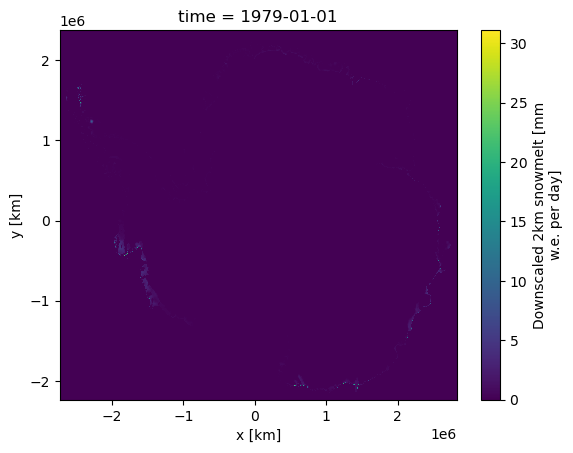

In [10]:
ds.snowmeltcorr.isel(time=0).plot()

In [16]:
ds.snowmeltcorr.isel(time=slice(0,1000)).mean().compute()

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 10.02 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'snowmeltcorr' ()> Size: 4B
array(0.01580478, dtype=float32)
Attributes:
    standard_name:  Downscaled_2km_snowmelt
    long_name:      Downscaled 2km snowmelt
    units:          mm w.e. per day
    actual_range:   [0.0, 291.7160949707031]

In [8]:
import xarray as xr
import s3fs

target = (
    "s3://nasa-cryo-scratch/"
    "jkingslake/Daily-2km/snowmelt_test_001.zarr"
)

ds.to_zarr(
    target,
    mode="w",
    consolidated=True
)